# **ُEDA and Preprocessing**

# FIFA Players Market Value & Performance Analysis Report

## 1. Project Overview
The objective of this project is to leverage machine learning techniques to analyze and predict FIFA player metrics:
* **Regression:** Predicting the market value of players (`Value Per M$`).
* **Classification:** Grouping players into performance tiers based on their `Overall_Rating`.
* **Feature Engineering Innovation:** Transforming high-cardinality categorical data (1,009 teams and 164 countries) into meaningful, low-dimensional clusters to improve model generalizability.

---

## 2. Advanced Feature Engineering & EDA
In this phase, we moved beyond basic data cleaning to structural data transformation:
* **Continent Mapping:** Replaced the `Country` column (164 unique values) with a `Continent` column. This reduces noise and groups players by geographical regions, which is more statistically significant for large-scale analysis.
* **Team Tier Clustering (K-Means):** Since the dataset contained **1,009 unique teams**, traditional encoding would lead to a "Curse of Dimensionality." Instead, we:
    * Grouped teams by their average `Overall_Rating` and `Value Per M$`.
    * Applied **K-Means Clustering** to segment all teams into 4 distinct categories: **Elite, High, Medium, and Low Tiers**.
* **Target Distribution:** Observed a **right-skewed distribution** in `Value Per M$`, emphasizing the need for robust scaling.

---

## 3. Data Splitting & Leakage Prevention
To ensure robust evaluation:
* **Split Ratio:** 80% Training / 20% Testing.
* **Stratification:** Applied to the classification target to ensure balanced performance tiers across both sets.
* **Integrity Protocol:** All transformations (Scaling and Encoding parameters) were learned from the **Training Set only** and then applied to the Test Set to prevent data leakage.

---

## 4. Optimized Preprocessing Pipeline
We implemented a multi-path `ColumnTransformer` to handle features based on their mathematical nature:

### A. Numerical Path (`Age`, `Overall_Rating`, `Future Potential`, `Total_Stats Score`)
* **Processing:** `SimpleImputer(strategy='mean')` followed by `StandardScaler()`.
* **Goal:** Ensures that features with different scales contribute equally to the model's weight calculation.

### B. Nominal Categorical Path (`Continent`, `Position`)
* **Processing:** `OneHotEncoder(handle_unknown='ignore', sparse_output=False)`.
* **Goal:** Converts regions and play styles into binary features without implying a mathematical order.

### C. Ordinal Categorical Path (`Team_Tier`)
* **Processing:** `OrdinalEncoder` with a explicitly defined sequence: 
  `['Low Tier' < 'Medium Tier' < 'High Tier' < 'Elite Tier']`.
* **Goal:** (Critical Update) This allows the model to understand the inherent rank of a team's prestige, preserving the logical relationship that an "Elite" team is superior to a "Low" tier team.

---

## 5. Current Progress & Data Readiness
* **Dimensionality Optimization:** By using Clustering and Ordinal Encoding, we significantly reduced the feature space, preventing the model from becoming over-complex.
* **Data Storage:**
    * **Features:** Saved as `X_train_transformed.csv` and `X_test_transformed.csv` with full column headers for transparency.
    * **Targets:** Saved as `.csv` for both Regression and Classification tasks.
* **Status:** The dataset is now fully cleaned, engineered, and structured for the Model Selection and Training phase.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Fifa.csv')

display(df.head())
df.info()

print(f"Number of duplicate rows: {df.duplicated().sum()}")

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640


<class 'pandas.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               19667 non-null  str    
 1   Country            19667 non-null  str    
 2   Position           19667 non-null  str    
 3   Age                19667 non-null  int64  
 4   Overall_Rating     19667 non-null  int64  
 5   Future Potential   19667 non-null  int64  
 6   Team               19667 non-null  str    
 7   Value Per M$       19667 non-null  float64
 8   Total_Stats Score  19667 non-null  int64  
dtypes: float64(1), int64(4), str(4)
memory usage: 1.4 MB
Number of duplicate rows: 0


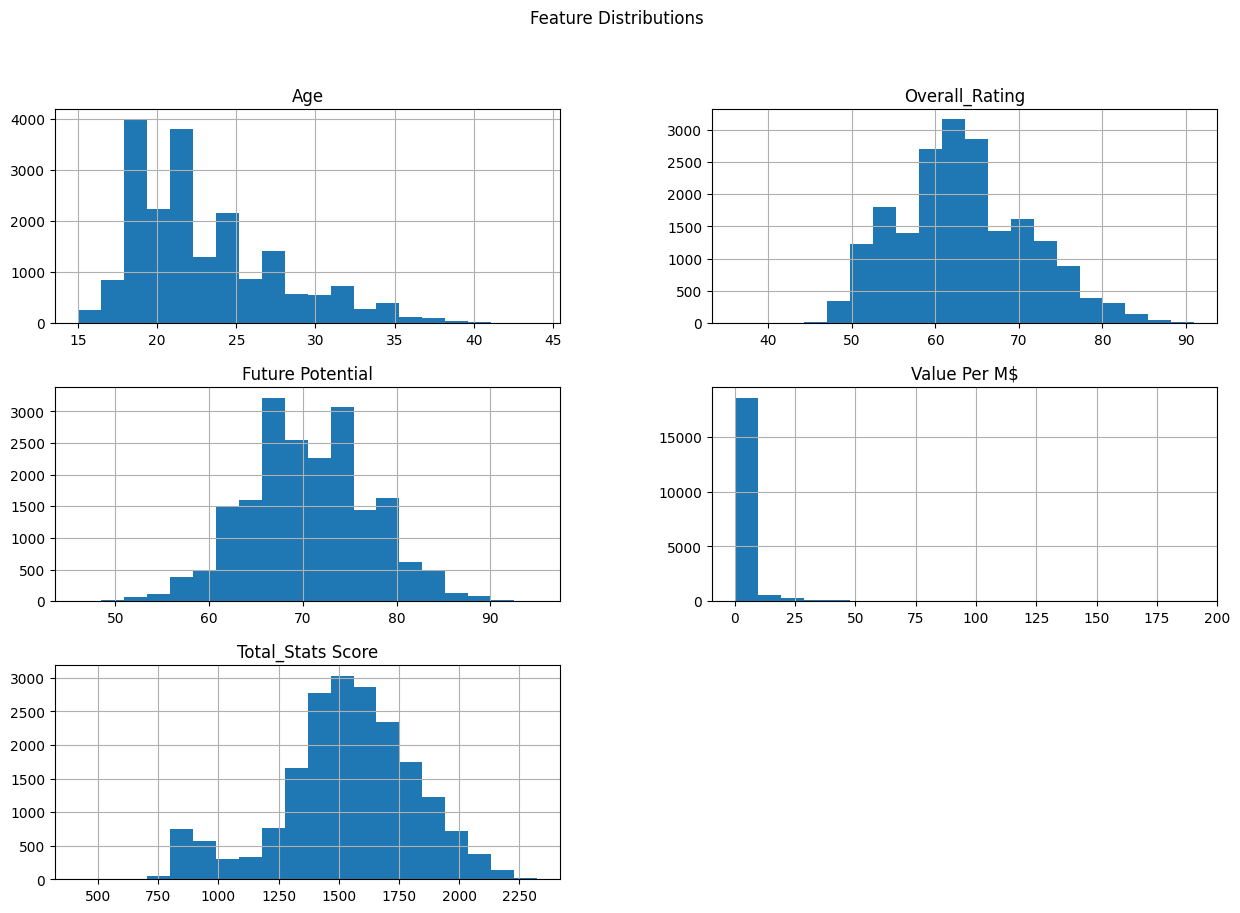

In [12]:
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(figsize=(15,10), bins=20)
plt.suptitle("Feature Distributions")
plt.show()

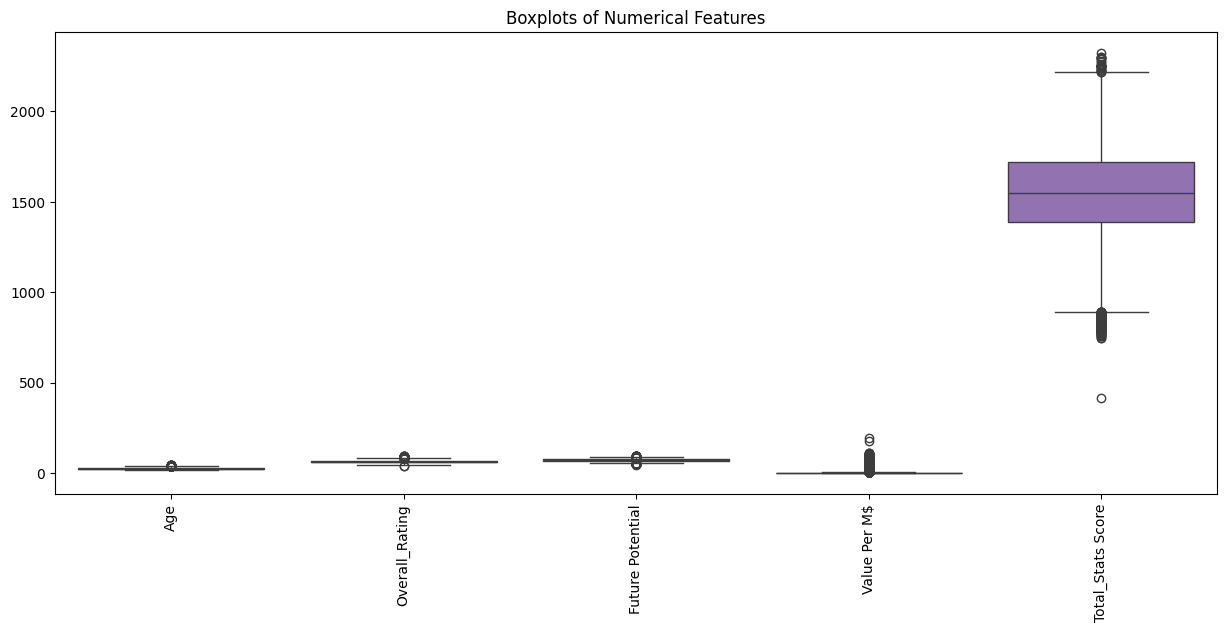

In [13]:
plt.figure(figsize=(15,6))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=90)
plt.title("Boxplots of Numerical Features")
plt.show()

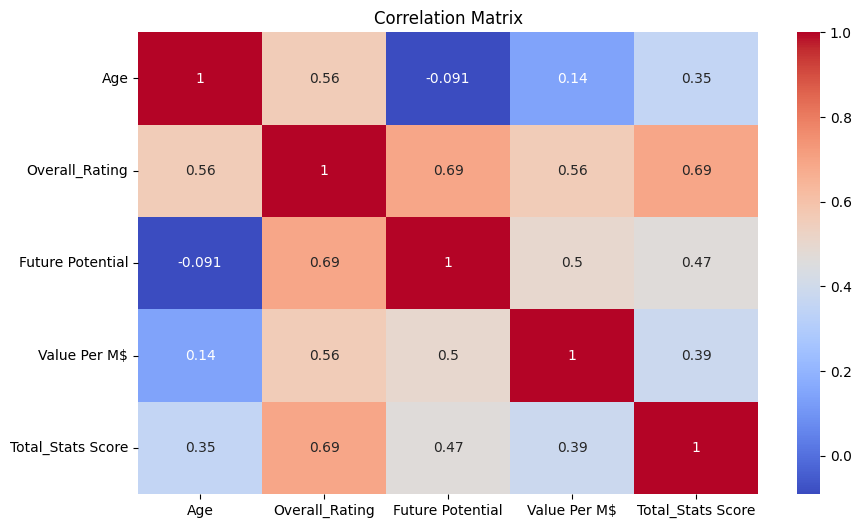

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

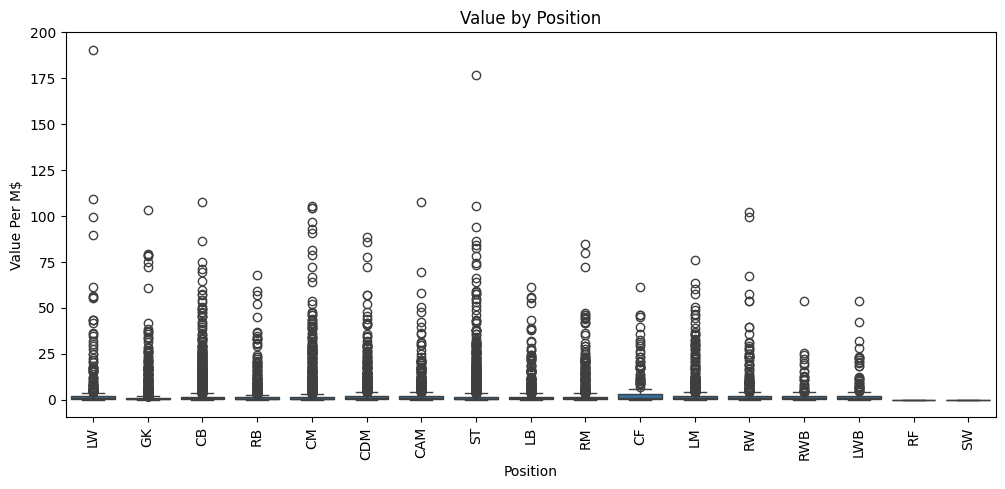

In [15]:
plt.figure(figsize=(12,5))
sns.boxplot(x='Position', y='Value Per M$', data=df)
plt.xticks(rotation=90)
plt.title("Value by Position")
plt.show()

In [16]:
# Country to Continent mapping dictionary
country_to_continent = {
    # Africa
    'Angola': 'Africa', 'Egypt': 'Africa', 'Nigeria': 'Africa', 'Senegal': 'Africa', 
    'Côte d\'Ivoire': 'Africa', 'Ghana': 'Africa', 'Morocco': 'Africa', 'Libya': 'Africa', 
    'Algeria': 'Africa', 'Burkina Faso': 'Africa', 'Gabon': 'Africa', 'Cameroon': 'Africa', 
    'Guinea': 'Africa', 'Mali': 'Africa', 'Gambia': 'Africa', 'Central African Republic': 'Africa', 
    'Liberia': 'Africa', 'Congo DR': 'Africa', 'Burundi': 'Africa', 'Zambia': 'Africa', 
    'Tunisia': 'Africa', 'Togo': 'Africa', 'Kenya': 'Africa', 'Zimbabwe': 'Africa', 
    'Sierra Leone': 'Africa', 'Guinea Bissau': 'Africa', 'Equatorial Guinea': 'Africa', 
    'Cape Verde Islands': 'Africa', 'South Africa': 'Africa', 'Mozambique': 'Africa', 
    'Mauritania': 'Africa', 'Tanzania': 'Africa', 'South Sudan': 'Africa', 'Congo': 'Africa', 
    'Seychelles': 'Africa', 'Uganda': 'Africa', 'Comoros': 'Africa', 'Benin': 'Africa', 
    'Madagascar': 'Africa', 'Chad': 'Africa', 'Niger': 'Africa', 'Malawi': 'Africa', 
    'Sudan': 'Africa', 'Ethiopia': 'Africa', 'Namibia': 'Africa', 
    # Europe
    'Ukraine': 'Europe', 'England': 'Europe', 'France': 'Europe', 'Belgium': 'Europe', 
    'Spain': 'Europe', 'Georgia': 'Europe', 'Hungary': 'Europe', 'Republic of Ireland': 'Europe', 
    'Italy': 'Europe', 'Germany': 'Europe', 'Netherlands': 'Europe', 'Denmark': 'Europe', 
    'Turkey': 'Europe', 'Portugal': 'Europe', 'Norway': 'Europe', 'Croatia': 'Europe', 
    'Serbia': 'Europe', 'Czech Republic': 'Europe', 'Albania': 'Europe', 'Wales': 'Europe', 
    'Slovenia': 'Europe', 'Sweden': 'Europe', 'Poland': 'Europe', 'Austria': 'Europe', 
    'Slovakia': 'Europe', 'Kosovo': 'Europe', 'Switzerland': 'Europe', 'Scotland': 'Europe', 
    'Greece': 'Europe', 'Luxembourg': 'Europe', 'Romania': 'Europe', 'Bosnia and Herzegovina': 'Europe', 
    'North Macedonia': 'Europe', 'Northern Ireland': 'Europe', 'Iceland': 'Europe', 'Armenia': 'Europe', 
    'Bulgaria': 'Europe', 'Finland': 'Europe', 'Russia': 'Europe', 'Cyprus': 'Europe', 
    'Montenegro': 'Europe', 'Malta': 'Europe', 'Azerbaijan': 'Europe', 'Moldova': 'Europe', 
    'Lithuania': 'Europe', 'Latvia': 'Europe', 'Andorra': 'Europe', 'Estonia': 'Europe', 
    'Liechtenstein': 'Europe', 'Faroe Islands': 'Europe', 'Belarus': 'Europe', 'Gibraltar': 'Europe', 
    # Asia
    'Japan': 'Asia', 'Korea Republic': 'Asia', 'Qatar': 'Asia', 'Israel': 'Asia', 
    'Iran': 'Asia', 'China PR': 'Asia', 'Iraq': 'Asia', 'Saudi Arabia': 'Asia', 
    'Jordan': 'Asia', 'Uzbekistan': 'Asia', 'India': 'Asia', 'Korea DPR': 'Asia', 
    'Philippines': 'Asia', 'Palestine': 'Asia', 'United Arab Emirates': 'Asia', 
    'Afghanistan': 'Asia', 'Vietnam': 'Asia', 'Kazakhstan': 'Asia', 'Tajikistan': 'Asia', 
    'Hong Kong': 'Asia', 'Syria': 'Asia', 'Thailand': 'Asia', 'Nepal': 'Asia', 
    'Singapore': 'Asia', 'Bhutan': 'Asia', 'Indonesia': 'Asia', 'Lebanon': 'Asia', 
    'Malaysia': 'Asia', 'Chinese Taipei': 'Asia', 
    # North America
    'Mexico': 'North America', 'Canada': 'North America', 'United States': 'North America', 
    'Jamaica': 'North America', 'Puerto Rico': 'North America', 'Costa Rica': 'North America', 
    'Trinidad and Tobago': 'North America', 'Panama': 'North America', 'Dominican Republic': 'North America', 
    'Curacao': 'North America', 'Haiti': 'North America', 'El Salvador': 'North America', 
    'Honduras': 'North America', 'Guatemala': 'North America', 'Cuba': 'North America', 
    'Bermuda': 'North America', 'Montserrat': 'North America', 'Grenada': 'North America', 
    'Saint Kitts and Nevis': 'North America', 'Saint Lucia': 'North America', 'Barbados': 'North America', 
    # South America
    'Uruguay': 'South America', 'Paraguay': 'South America', 'Argentina': 'South America', 
    'Ecuador': 'South America', 'Brazil': 'South America', 'Chile': 'South America', 
    'Colombia': 'South America', 'Peru': 'South America', 'Venezuela': 'South America', 
    'Suriname': 'South America', 'Bolivia': 'South America', 'Guyana': 'South America', 
    # Oceania
    'Australia': 'Oceania', 'New Zealand': 'Oceania', 'Papua New Guinea': 'Oceania', 
    'Vanuatu': 'Oceania', 'New Caledonia': 'Oceania'
}

# Create Continent column
df['Continent'] = df['Country'].map(country_to_continent)

# Drop original Country column
df.drop(columns=['Country'], inplace=True)

# Save processed data
df.to_csv('Fifa_with_Continents.csv', index=False)

print("Done: 'Country' column replaced with 'Continent'.")

Done: 'Country' column replaced with 'Continent'.


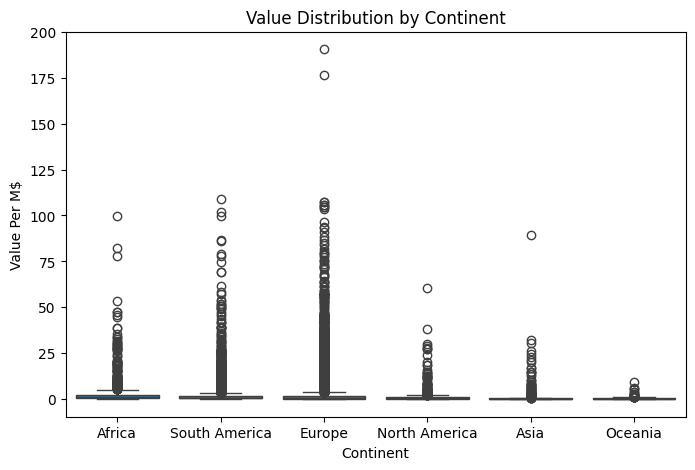

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Continent', y='Value Per M$', data=df)
plt.title("Value Distribution by Continent")
plt.show()

In [18]:
def assign_tier(rating):
    if rating >= 80:
        return 'Elite'
    elif rating >= 70:
        return 'High'
    elif rating >= 60:
        return 'Mid'
    else:
        return 'Low'

df['Performance_Tier'] = df['Overall_Rating'].apply(assign_tier)

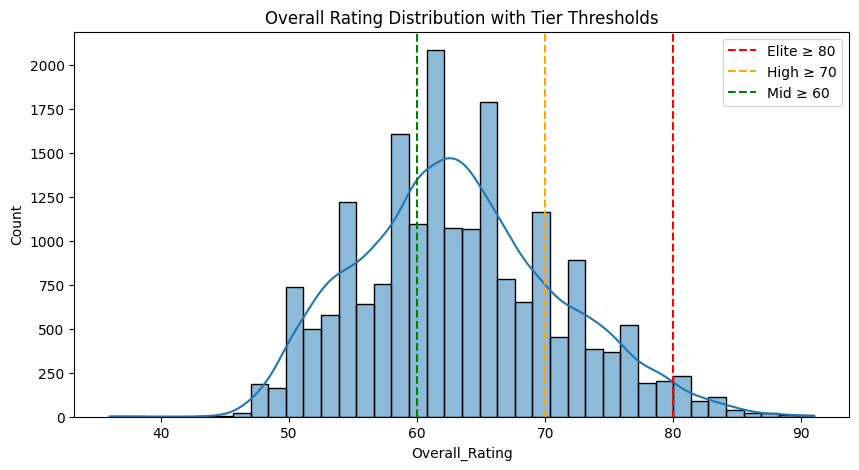

Thresholds chosen based on natural breaks in FIFA ratings:
Elite  : Overall_Rating ≥ 80 (top-tier stars)
High   : 70 ≤ Overall_Rating < 80 (very good players)
Mid    : 60 ≤ Overall_Rating < 70 (solid professionals)
Low    : Overall_Rating < 60 (developing or lower-league players)

Full dataset class distribution:
Performance_Tier
Mid      9148
Low      6417
High     3579
Elite     523
Name: count, dtype: int64


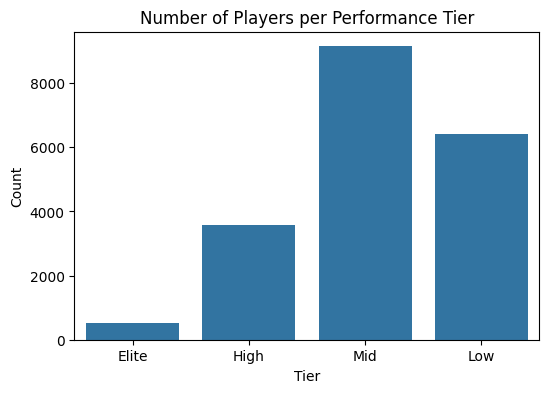

The classes are somewhat imbalanced: Low + Mid tiers dominate. We will use stratified splitting.


In [19]:

plt.figure(figsize=(10,5))
sns.histplot(df['Overall_Rating'], bins=40, kde=True)
plt.axvline(80, color='red', linestyle='--', label='Elite ≥ 80')
plt.axvline(70, color='orange', linestyle='--', label='High ≥ 70')
plt.axvline(60, color='green', linestyle='--', label='Mid ≥ 60')
plt.legend()
plt.title('Overall Rating Distribution with Tier Thresholds')
plt.show()

print("Thresholds chosen based on natural breaks in FIFA ratings:")
print("Elite  : Overall_Rating ≥ 80 (top-tier stars)")
print("High   : 70 ≤ Overall_Rating < 80 (very good players)")
print("Mid    : 60 ≤ Overall_Rating < 70 (solid professionals)")
print("Low    : Overall_Rating < 60 (developing or lower-league players)")

# Count players in each tier (full dataset)
tier_counts = df['Performance_Tier'].value_counts()
print("\nFull dataset class distribution:")
print(tier_counts)

# Bar chart
plt.figure(figsize=(6,4))
sns.barplot(x=tier_counts.index, y=tier_counts.values, order=['Elite','High','Mid','Low'])
plt.title('Number of Players per Performance Tier')
plt.xlabel('Tier')
plt.ylabel('Count')
plt.show()

# Quick balance comment
print("The classes are somewhat imbalanced: Low + Mid tiers dominate. We will use stratified splitting.")

In [20]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Name', 'Value Per M$', 'Performance_Tier'])
y_reg = df['Value Per M$']
y_clf = df['Performance_Tier']

X_train, X_test, y_train_reg, y_test_reg, y_train_clf, y_test_clf = train_test_split(
    X, y_reg, y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

In [21]:
# Task 2: Detect and handle outliers using IQR on numerical features (train only, then apply to test)

# Numerical columns in the current feature set (before clustering/dropping)
num_cols = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']
target_col = 'Value Per M$'

# Calculate IQR bounds from training data only
feature_bounds = {}
for col in num_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    feature_bounds[col] = (lower, upper)

# For target
Q1_tar = y_train_reg.quantile(0.25)
Q3_tar = y_train_reg.quantile(0.75)
IQR_tar = Q3_tar - Q1_tar
target_lower = Q1_tar - 1.5 * IQR_tar
target_upper = Q3_tar + 1.5 * IQR_tar

# Clip numerical features in X_train and X_test
for col, (lower, upper) in feature_bounds.items():
    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col]  = X_test[col].clip(lower, upper)

# Clip target similarly
y_train_reg = y_train_reg.clip(target_lower, target_upper)
y_test_reg  = y_test_reg.clip(target_lower, target_upper)

print("Outliers capped using IQR bounds (1.5×IQR).")
print("Target bounds: [{:.2f}, {:.2f}]".format(target_lower, target_upper))
for col, (l, u) in feature_bounds.items():
    print(f"{col}: [{l:.2f}, {u:.2f}]")

Outliers capped using IQR bounds (1.5×IQR).
Target bounds: [-1.59, 3.51]
Age: [8.50, 36.50]
Overall_Rating: [43.00, 83.00]
Future Potential: [52.50, 88.50]
Total_Stats Score: [894.00, 2214.00]


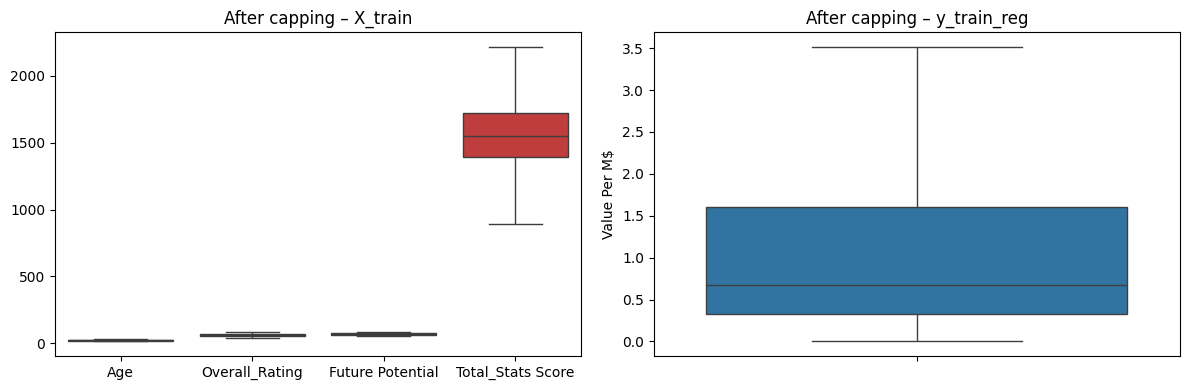

In [22]:
# Quick boxplot after capping to confirm outliers are contained
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(data=X_train[['Age','Overall_Rating','Future Potential','Total_Stats Score']], ax=axes[0])
axes[0].set_title('After capping – X_train')
sns.boxplot(y=y_train_reg, ax=axes[1])
axes[1].set_title('After capping – y_train_reg')
plt.tight_layout()
plt.show()

In [23]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [24]:

# 🔹 train only
train_temp = X_train.copy()
train_temp['Value Per M$'] = y_train_reg

team_stats_train = train_temp.groupby('Team').agg({
    'Overall_Rating': 'mean'
}).reset_index()

scaler_team = StandardScaler()
scaled_train = scaler_team.fit_transform(team_stats_train[['Overall_Rating']])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

team_stats_train['Cluster_ID'] = kmeans.fit_predict(scaled_train)

# ترتيب tiers
cluster_order = team_stats_train.groupby('Cluster_ID')['Overall_Rating'].mean().sort_values(ascending=False).index

tier_labels = {
    cluster_order[0]: 'Elite Tier',
    cluster_order[1]: 'High Tier',
    cluster_order[2]: 'Medium Tier',
    cluster_order[3]: 'Low Tier'
}

team_stats_train['Team_Tier'] = team_stats_train['Cluster_ID'].map(tier_labels)

# mapping من train فقط
team_mapping = dict(zip(team_stats_train['Team'], team_stats_train['Team_Tier']))

# apply على train/test
X_train['Team_Tier'] = X_train['Team'].map(team_mapping)
X_test['Team_Tier'] = X_test['Team'].map(team_mapping)

# فرق مش موجودة في train
X_test['Team_Tier'].fillna('Low Tier', inplace=True)

# drop Team
X_train.drop(columns=['Team'], inplace=True)
X_test.drop(columns=['Team'], inplace=True)

C:\Users\david\AppData\Local\Temp\ipykernel_6236\2782443271.py:36: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  X_test['Team_Tier'].fillna('Low Tier', inplace=True)


In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

numeric_features = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']
onehot_features = ['Continent', 'Position']
ordinal_features = ['Team_Tier']

tier_order = ['Low Tier', 'Medium Tier', 'High Tier', 'Elite Tier']

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

onehot_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

ordinal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[tier_order]))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat_onehot', onehot_transformer, onehot_features),
    ('cat_ordinal', ordinal_transformer, ordinal_features)
])

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [26]:
column_names = preprocessor.get_feature_names_out()

X_train_final = pd.DataFrame(X_train_transformed, columns=column_names)
X_test_final = pd.DataFrame(X_test_transformed, columns=column_names)

X_train_final.to_csv('X_train_transformed.csv', index=False)
X_test_final.to_csv('X_test_transformed.csv', index=False)

y_train_reg.to_csv('y_train_reg.csv', index=False)
y_test_reg.to_csv('y_test_reg.csv', index=False)

y_train_clf.to_csv('y_train_clf.csv', index=False)
y_test_clf.to_csv('y_test_clf.csv', index=False)

print("Saved successfully ✅")

Saved successfully ✅
